# OpenStreetMap and street networks
## MUSA-5500 · A step-by-step class notebook

We will start with a map, then get a few features, build a street network, and find a route. After the break, we will ask: **does an 800-meter circle describe a ten-minute walk to a station?**

Run one cell at a time. Before each plot, pause and predict what you will see.

This follows the style and sequence of the [Week 8A tutorial](https://xiaojianggis.github.io/MUSA-5500-Geospatial-Data-Science-Python/labs/week-8-network-analysis/week-8A-street-network.html). Setup instructions are in `START_HERE.md`. Keep this notebook beside the supplied `cache/` and `data/` folders.

**Offline backup:** the download cells load the same data from local files. All teaching steps are otherwise identical.

## 1. What is OpenStreetMap?
First, explore [OpenStreetMap around Penn](https://www.openstreetmap.org/#map=16/39.9520/-75.1910) in the browser.

Find a street, a building, and a station. Open [34th Street station](https://www.openstreetmap.org/node/4179747391). Its tags tell us what the object means.

**Look for:** `name`, `railway`, `station`, and `network`.

OSM is the geographic database. **OSMnx** is a Python package that helps us use its data.

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Reuse saved downloads, including those supplied with this notebook.
ox.settings.use_cache = True
ox.settings.cache_folder = "cache"

## 2. Find Philadelphia
We begin with a familiar GeoDataFrame: the city boundary.

In [3]:
philly = gpd.read_file("data/philly.geojson")
philly[["display_name", "geometry"]]

,display_name,geometry
0,"Philadelphia, Philadelphia County, Pennsylvani...","POLYGON ((-75.28027 39.97496, -75.28023 39.974..."


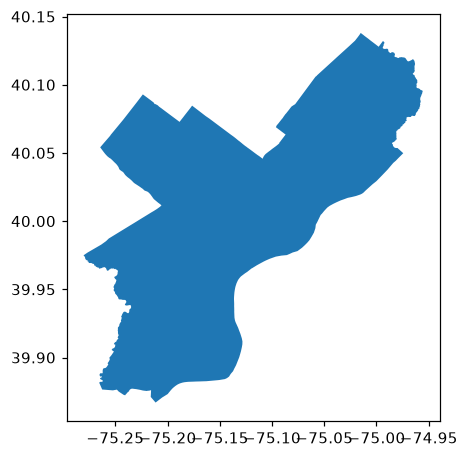

In [4]:
philly.plot()
plt.show()

### Degrees or meters?
The downloaded boundary uses longitude and latitude. For local distances and buffers, project it to UTM zone 18N.

In [5]:
philly.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

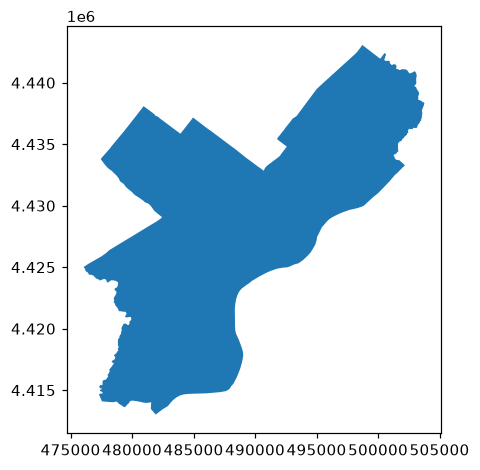

In [6]:
philly_m = philly.to_crs("EPSG:32618")
philly_m.plot()
plt.show()

## 3. What is around a station?
Our center is 34th Street station in University City. OSMnx point queries take **(latitude, longitude)**.

We will request nearby cafes using one tag.

In [7]:
center = (39.9559238, -75.1914953)
cafes = gpd.read_file("data/cafes.geojson")

In [8]:
cafes[["name", "amenity", "geometry"]].head()

,name,amenity,geometry
0,Starbucks,cafe,POINT (-75.19229 39.95301)
1,Saxbys,cafe,POINT (-75.20305 39.95288)
2,Top Hat Coffee Lounge,cafe,POINT (-75.18709 39.95233)
3,Saxbys,cafe,POINT (-75.188 39.95498)
4,Starbucks,cafe,POINT (-75.19938 39.95247)


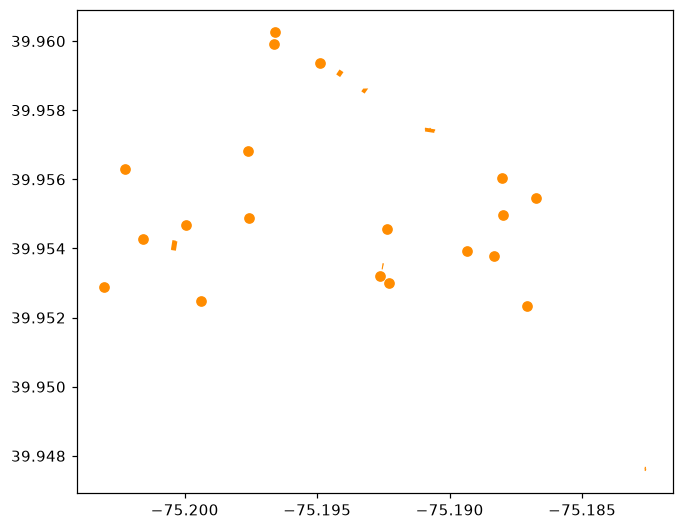

In [9]:
cafes.plot(color="darkorange", figsize=(7, 7))
plt.show()

**Your turn:** which tag would you change to look for restaurants? Predict before editing.

OSM features may be points or polygons. A cafe feature count is not automatically a count of unique businesses. For today's class, we simply inspect what OSM returns.

## 4. Get a walking network
Now we want the connections between places. One function builds the graph.

We download a larger area than the 1,200 m neighborhood used later, so short routes can cross its boundary. The default keeps the largest connected component.

In [10]:
G = ox.load_graphml("data/walk.graphml")

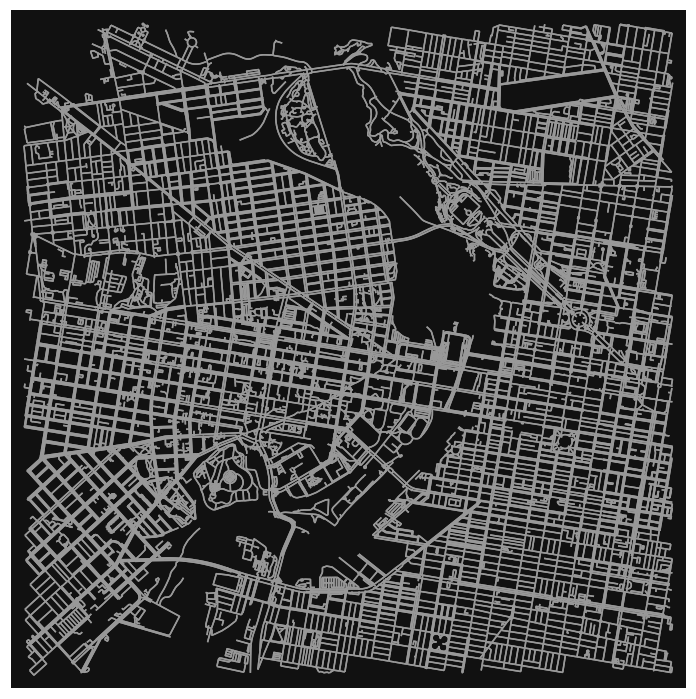

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [11]:
ox.plot_graph(G, node_size=0)

### Does travel mode change the network?
For this comparison, use a smaller area so individual streets are easy to see.

In [12]:
G_drive = ox.load_graphml("data/drive.graphml")
G_walk = ox.load_graphml("data/walk_small.graphml")

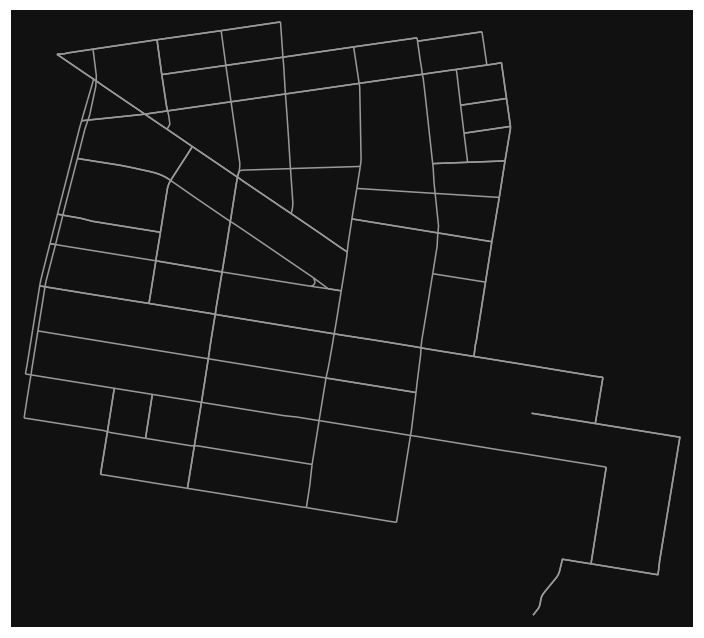

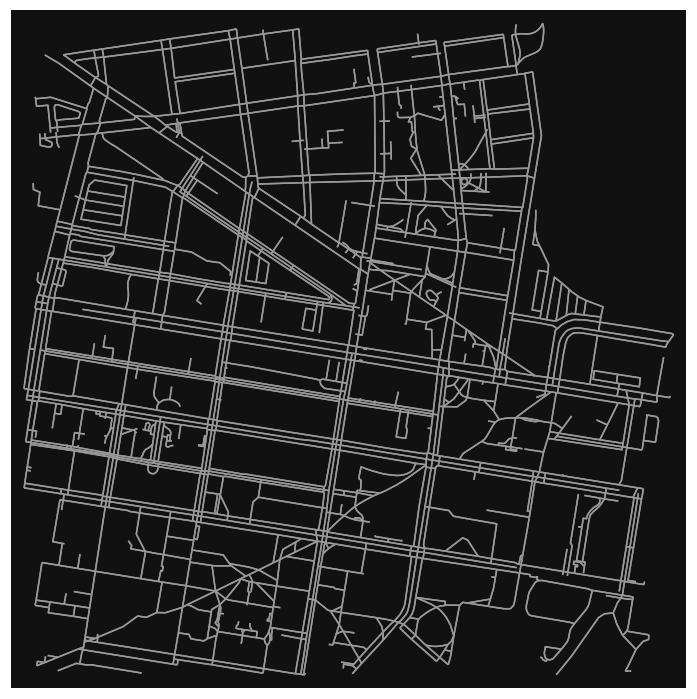

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [13]:
ox.plot_graph(G_drive, node_size=0)
ox.plot_graph(G_walk, node_size=0)

**Pause:** find a connection that appears in the walking network but not the driving network. Why might it be there?

## 5. What is inside the graph?
A graph contains **nodes** and **edges**. Direction matters, and more than one edge may connect two nodes. OSMnx stores this as a `MultiDiGraph`.

In [14]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [15]:
len(G.nodes), len(G.edges)

(16637, 51428)

We can also view the graph as two GeoDataFrames. The graph is useful for routes. The tables are useful for inspecting attributes and plotting.

In [16]:
G_m = ox.project_graph(G)
nodes, edges = ox.graph_to_gdfs(G_m)

In [17]:
nodes[["x", "y", "geometry"]].head()

,x,y,geometry
osmid,,,
109727353,485223.173841,4.420539e+06,POINT (485223.174 4420538.576)
109727357,485198.570945,4.420404e+06,POINT (485198.571 4420404.249)
110024116,485270.834427,4.420531e+06,POINT (485270.834 4420530.504)
109924749,485183.209066,4.420545e+06,POINT (485183.209 4420545.346)
109924757,485158.818726,4.420411e+06,POINT (485158.819 4420410.83)


In [18]:
edges[["length", "highway", "geometry"]].head()

length  ...                                           geometry
u         v         key              ...                                                   
109727353 109727357 0    136.797865  ...  LINESTRING (485223.174 4420538.576, 485198.571...
          110024116 0     48.243085  ...  LINESTRING (485223.174 4420538.576, 485270.834...
          109924749 0     40.453437  ...  LINESTRING (485223.174 4420538.576, 485183.209...
109727357 109727353 0    136.797865  ...  LINESTRING (485198.571 4420404.249, 485223.174...
          109924757 0     40.212876  ...  LINESTRING (485198.571 4420404.249, 485158.819...

[5 rows x 3 columns]

`length` is in meters. Edge rows use `(u, v, key)` as an index.

**Think:** does every bend in a street need to be an intersection? OSMnx simplifies shape points while keeping the curved edge geometry.

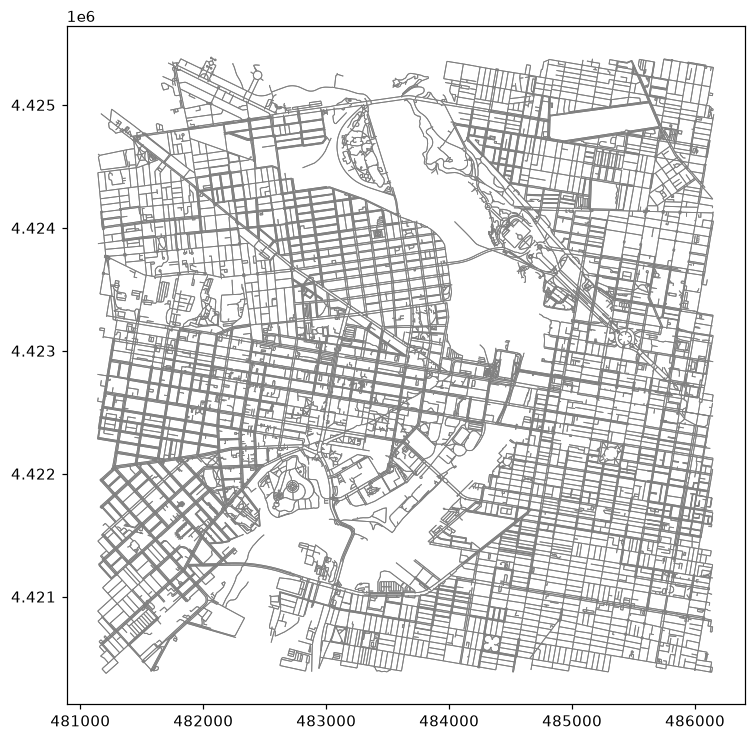

In [19]:
edges.plot(color="gray", linewidth=0.6, figsize=(8, 8))
plt.show()

## 6. A first route
Let's walk from a point near Penn to 34th Street station.

`nearest_nodes` attaches each location to the graph. It takes **X = longitude, Y = latitude** for this unprojected graph.

In [20]:
origin = ox.nearest_nodes(G, X=-75.193, Y=39.952)
station_node = ox.nearest_nodes(G, X=center[1], Y=center[0])

In [21]:
route = ox.shortest_path(G, origin, station_node, weight="length")
route[:5]

[360481589, 360481482, 1684000552, 3370980184, 1688839952]

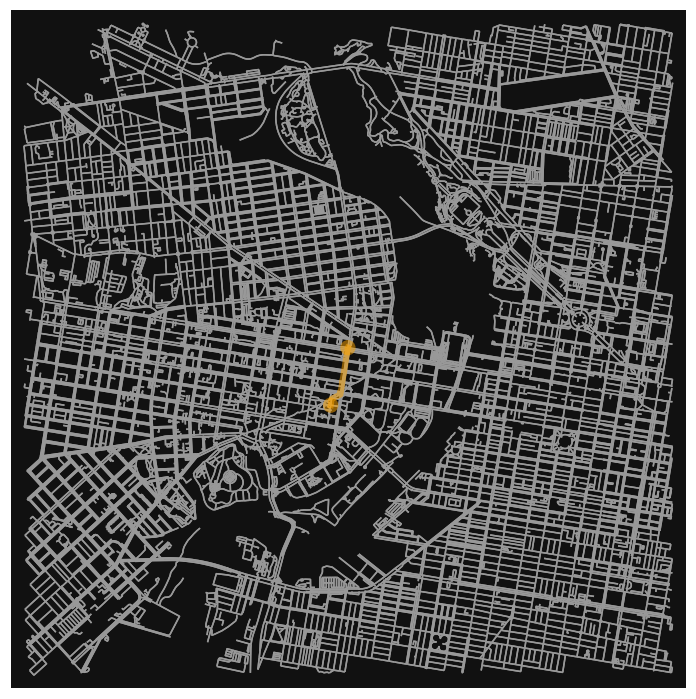

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [22]:
ox.plot_graph_route(G, route, node_size=0, route_color="orange")

The route is a list of node IDs. We can retrieve its edge table and add up the lengths.

In [23]:
route_edges = ox.routing.route_to_gdf(G, route)
route_m = route_edges["length"].sum()
route_m

np.float64(497.53599019313134)

In [24]:
speed = 80  # meters per minute: a teaching assumption
route_m / speed

np.float64(6.219199877414142)

**Question:** with the same speed on every edge, would the shortest walking-time route differ from the shortest-distance route?

We have calculated travel between **snapped graph nodes**. Reaching the exact doorway or platform would require better endpoint data and additional time.

# Section 2. Is “near” the same as “walkable”?
## 7. Draw an 800-meter circle
At 80 meters per minute, ten minutes corresponds to 800 meters.

We will compare both methods at the **same snapped station node**. This keeps the code and comparison simple. The station point is an approximation, not a verified entrance.

In [25]:
minutes = 10
budget = speed * minutes
budget

800

In [26]:
station_point = nodes.loc[station_node, "geometry"]
station = gpd.GeoSeries([station_point], crs=nodes.crs)
circle = station.buffer(budget)

Use street nodes within 1,200 m of this station as our study locations. This is a local example, not a count of residents or all Philadelphia stations.

In [27]:
nearby = nodes[nodes.distance(station_point) <= 1200].copy()
nearby["straight_m"] = nearby.distance(station_point)

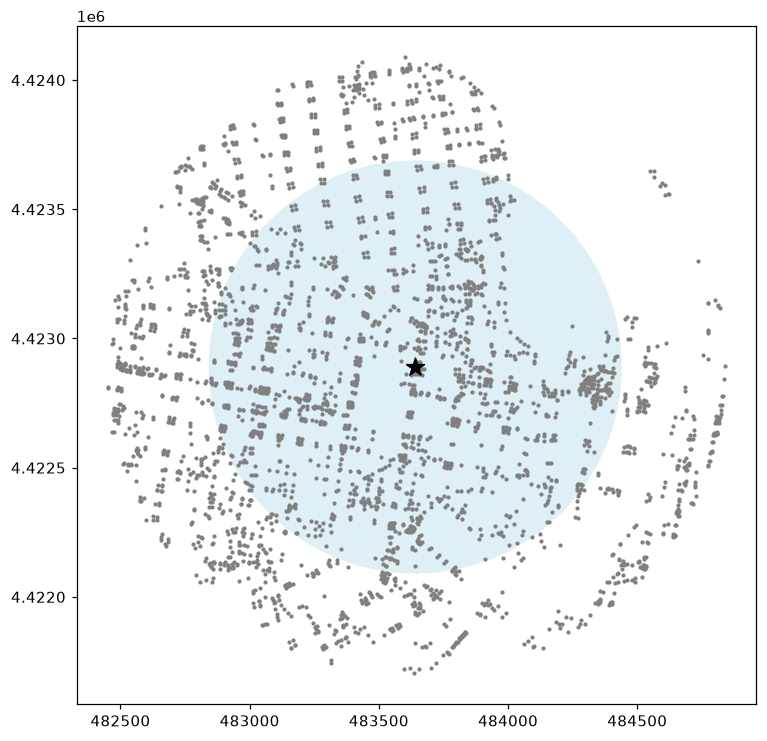

In [28]:
ax = circle.plot(color="lightblue", alpha=0.4, figsize=(8, 8))
nearby.plot(ax=ax, color="gray", markersize=3)
station.plot(ax=ax, color="black", marker="*", markersize=150)
plt.show()

**Predict:** will all the street nodes inside the circle also be within an 800 m walk?

## 8. Calculate walking distances
NetworkX can calculate the shortest distance from one node to every other node.

We use `G_m.reverse()` to measure travel **toward** the station. The default walking graph permits travel in both directions, but this distinction matters for directed networks.

In [29]:
distance_to_station = nx.single_source_dijkstra_path_length(
    G_m.reverse(), station_node, weight="length"
)

In [30]:
nearby["walk_m"] = nearby.index.map(distance_to_station)
nearby["walk_m"] = nearby["walk_m"].fillna(float("inf"))

Match the distance dictionary to the node table by node ID. A missing route gets infinity, so it never counts as reachable.

In [31]:
nearby["inside_circle"] = nearby["straight_m"] <= budget
nearby["within_walk"] = nearby["walk_m"] <= budget
nearby[["straight_m", "walk_m", "inside_circle", "within_walk"]].head()

,straight_m,walk_m,inside_circle,within_walk
osmid,,,,
109775193,1188.428503,1793.966553,False,False
11340626578,1191.930432,1798.617786,False,False
6169144423,1184.828027,1789.161997,False,False
6169144421,1186.722189,1800.748044,False,False
109780100,189.093984,237.793695,True,True


## 9. Compare the maps
Blue nodes meet the walking threshold. Orange nodes are inside the circle but beyond the walking threshold.

In [32]:
walkable = nearby[nearby["within_walk"]]
disagreement = nearby[nearby["inside_circle"] & ~nearby["within_walk"]]

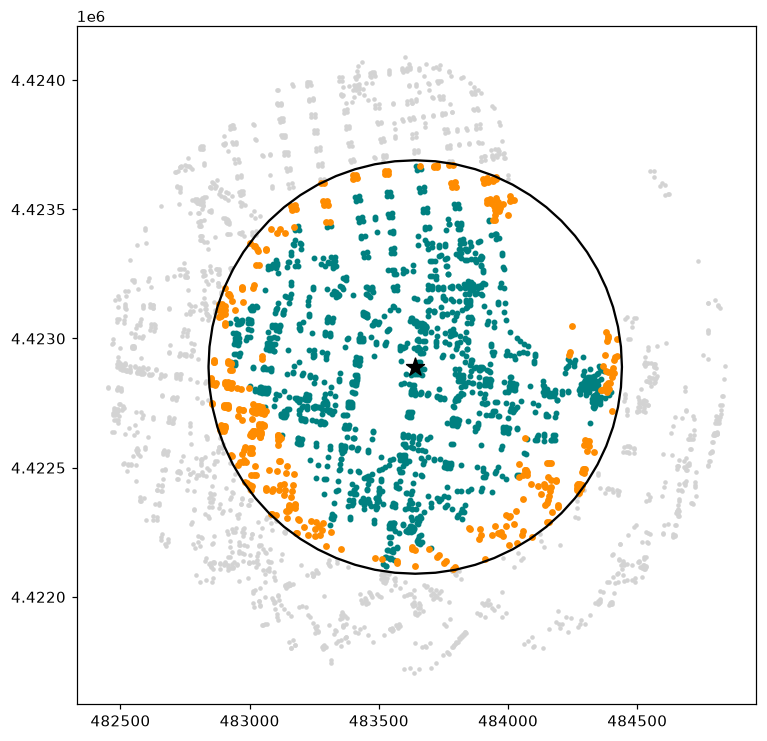

In [33]:
ax = circle.boundary.plot(color="black", figsize=(8, 8))
nearby.plot(ax=ax, color="lightgray", markersize=4)
walkable.plot(ax=ax, color="teal", markersize=8)
disagreement.plot(ax=ax, color="darkorange", markersize=12)
station.plot(ax=ax, color="black", marker="*", markersize=150)
plt.show()

In [34]:
counts = nearby[["inside_circle", "within_walk"]].sum()
counts.index = ["Straight-line", "Walking network"]
counts

Straight-line      1857
Walking network    1445
dtype: int64

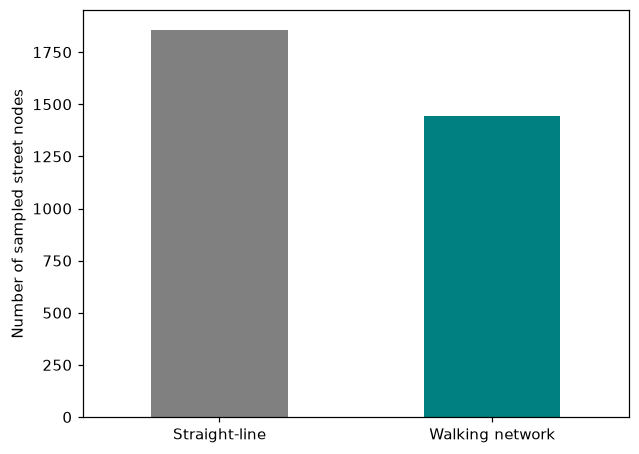

In [35]:
counts.plot.bar(color=["gray", "teal"], rot=0)
plt.ylabel("Number of sampled street nodes")
plt.show()

**Discussion 1 (3 minutes):** pick an orange location. Is the difference caused by street layout, a missing connection, or the station location? What would you inspect next?

The network catchment here is a **set of reachable street nodes**, not a filled land-area polygon. The counts describe those sampled nodes. They do not count people.

## 10. Change one assumption
What if a person walks at 60 meters per minute? No new data download is needed.

In [36]:
slower_budget = 60 * 10
nearby["slower_walk"] = nearby["walk_m"] <= slower_budget
nearby[["within_walk", "slower_walk"]].sum()

within_walk    1445
slower_walk     871
dtype: int64

**Your turn:** try 5 or 15 minutes at 80 m/min. Compare the counts before making another map.

Keep this exercise at or below 1,200 m. A larger threshold needs a larger study area and a boundary check.

## 11. A small extension: three stations
Now repeat the same idea for 30th, 34th, and 40th Street stations. The supplied file contains these three OSM station points only.

This answers “can a location reach **any of these three stations**?” It does not represent the entire transit system.

In [37]:
stations = gpd.read_file("data/stations.geojson").to_crs(nodes.crs)
stations[["name", "geometry"]]

,name,geometry
0,34th Street,POINT (483643.508 4422882.764)
1,30th Street,POINT (484328.783 4422782.387)
2,40th Street,POINT (482756.727 4423032.88)


In [38]:
station_nodes = ox.nearest_nodes(G_m, X=stations.geometry.x, Y=stations.geometry.y)

In [39]:
distance_to_any = nx.multi_source_dijkstra_path_length(
    G_m.reverse(), list(station_nodes), weight="length"
)

In [40]:
nearby["any_station_m"] = nearby.index.map(distance_to_any)
(nearby["any_station_m"] <= budget).sum()

np.int64(2448)

**Discussion 2 (3 minutes):** what else would we need to answer “which residents have useful transit access?”

Think about home locations, walking needs, real entrances, waiting time, and where the trains go.

### Where does Pandana fit?
If we repeatedly ask about the nearest cafe, school, or station at thousands of origins, Pandana offers convenient accessibility queries. The short, separate `02_Pandana_Optional.ipynb` shows this with the same graph. It is not needed for the core lesson.


Data © [OpenStreetMap contributors](https://www.openstreetmap.org/copyright), ODbL 1.0. Sources: [OSMnx](https://osmnx.readthedocs.io/en/stable/user-reference.html), [NetworkX](https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html).